### Phase 1: Foundation & Preprocessing.

#### 1. Initial Setup and Memory Optimization

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('data\Crime_Data_from_2020_to_Present.csv')

def optimize_memory(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

df = optimize_memory(df)

#### 2. Handling Missing Values and Column Drops

In [3]:
cols_to_drop = ['DR_NO', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'Mocodes']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df['Vict Sex'] = df['Vict Sex'].fillna('X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0) 

df.dropna(subset=['LAT', 'LON', 'Vict Age'], inplace=True)

#### 3. Temporal Feature Engineering

In [4]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['Month'] = df['DATE OCC'].dt.month
df['DayOfWeek'] = df['DATE OCC'].dt.dayofweek
df['Year'] = df['DATE OCC'].dt.year

df['Hour'] = (df['TIME OCC'] // 100).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['is_weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

C:\Users\aryam\AppData\Local\Temp\ipykernel_15660\1595819174.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


#### 4. Categorical Encoding (Target Preparation)

In [5]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
df['AREA_CODE'] = le_area.fit_transform(df['AREA NAME'])

le_crm = LabelEncoder()
df['CRM_TYPE_CODE'] = le_crm.fit_transform(df['Crm Cd Desc'])

#### 5.Data Quality Analysis Function

In [7]:
def generate_quality_report(df):
    report = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        '% Missing': (df.isnull().sum().values / len(df)) * 100,
        'Unique Values': df.nunique().values,
        'Min Value': [df[col].min() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns],
        'Max Value': [df[col].max() if np.issubdtype(df[col].dtype, np.number) else 'N/A' for col in df.columns]
    })
    
    return report.sort_values(by='% Missing', ascending=False)

quality_report = generate_quality_report(df)
print("LAPD Crime Data Quality Report")
print(quality_report)

LAPD Crime Data Quality Report
            Column       Data Type  Missing Values  % Missing  Unique Values  \
15     Weapon Desc          object          677744  67.437818             79   
13     Premis Desc          object             588   0.058508            306   
12       Premis Cd         float32              16   0.001592            314   
18        Crm Cd 1         float32              11   0.001095            142   
16          Status          object               1   0.000100              6   
3             AREA            int8               0   0.000000             21   
0        Date Rptd          object               0   0.000000           1896   
6         Part 1-2            int8               0   0.000000              2   
5      Rpt Dist No           int16               0   0.000000           1210   
7           Crm Cd           int16               0   0.000000            140   
8      Crm Cd Desc          object               0   0.000000            140   
10       

#### 6.Outlier Detection (Statistical Proof)

In [8]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

age_outliers, low, high = check_outliers(df, 'Vict Age')
print(f"Vict Age Outliers: {age_outliers} (Values outside {low:.1f} - {high:.1f})")

Vict Age Outliers: 1 (Values outside -66.0 - 110.0)


#### 7.Visualizing Data Distribution

C:\Users\aryam\AppData\Local\Temp\ipykernel_15660\570892338.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, palette='viridis')


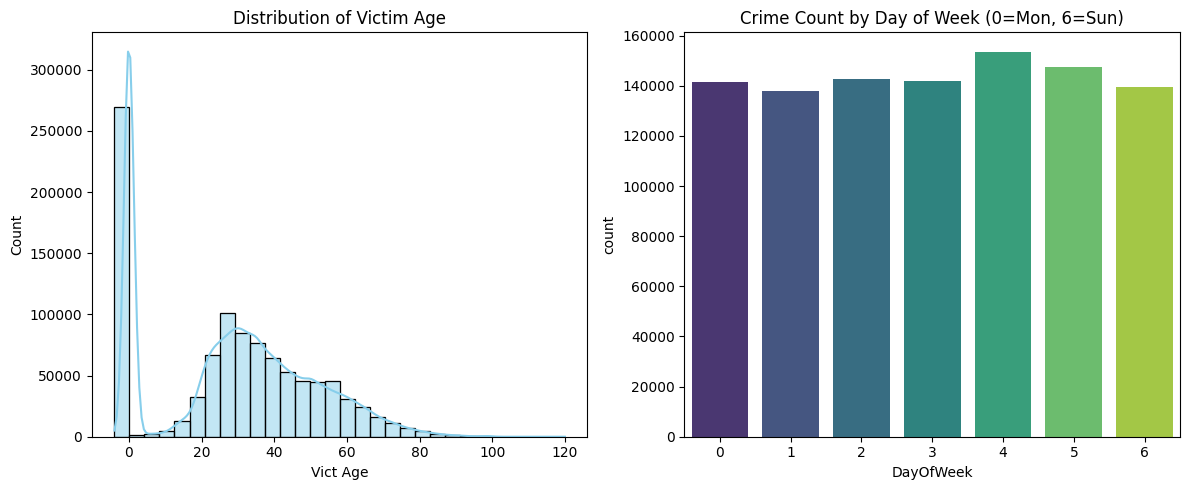

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Vict Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Victim Age')

plt.subplot(1, 2, 2)
sns.countplot(x='DayOfWeek', data=df, palette='viridis')
plt.title('Crime Count by Day of Week (0=Mon, 6=Sun)')

plt.tight_layout()
plt.show()

#### Saving the Cleaned Dataset

In [11]:
import os

output_path = '../data/NEW/cleaned_crime_data.csv'

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)

print(f"Cleaned data successfully saved to: {output_path}")
print(f"Final Row Count: {len(df)}")

Cleaned data successfully saved to: ../data/NEW/cleaned_crime_data.csv
Final Row Count: 1004991
